# Metrics and Model Comparison
## European Housing Price Forecasting - EU-26 Panel

**Course:** Machine Learning and Deep Learning, CBS Spring 2026

**Purpose:** Load all model predictions from `predictions.csv` and produce the full comparative evaluation across all phases. This notebook answers the three research questions:

- **RQ1:** Can ML models outperform benchmark approaches for forecasting next-quarter house price growth?
- **RQ2:** Does stratifying models by housing market regime (cluster) improve forecast accuracy over the pooled baseline?
- **RQ3:** Which macroeconomic and institutional factors most strongly drive short-term housing price dynamics, and do these vary across market regimes?

**Input:** `predictions.csv` (from `modelling.ipynb`)

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
})
ACCENT = '#2E5496'
RED    = '#C0392B'
GREEN  = '#1A7A4A'
AMBER  = '#F39C12'

candidate_paths = [
    Path('predictions.csv'),
    Path('./predictions.csv'),
    Path(r'C:\Users\carla\CBS\ml-final-project\s4-modelling\predictions.csv'),
]
preds_path = next((p for p in candidate_paths if p.exists()), None)
if preds_path is None:
    raise FileNotFoundError('predictions.csv not found. Run modelling.ipynb first.')

preds = pd.read_csv(preds_path)
print(f'Loaded: {preds.shape[0]} rows x {preds.shape[1]} columns')
print(f'Model columns: {[c for c in preds.columns if c not in ["country_code","country","quarter","year","cluster_data","cluster_literature","y_true"]]}')

Loaded: 364 rows x 42 columns
Model columns: ['naive_persistence', 'rolling_mean', 'ols', 'ridge', 'lasso', 'rf', 'gb', 'ridge_km0', 'lasso_km0', 'rf_km0', 'gb_km0', 'ridge_km1', 'lasso_km1', 'rf_km1', 'gb_km1', 'ridge_km2', 'lasso_km2', 'rf_km2', 'gb_km2', 'ridge_km3', 'lasso_km3', 'rf_km3', 'gb_km3', 'ridge_lit_east', 'lasso_lit_east', 'rf_lit_east', 'gb_lit_east', 'ridge_lit_west', 'lasso_lit_west', 'rf_lit_west', 'gb_lit_west', 'ridge_lit_south', 'lasso_lit_south', 'ridge_lit_north', 'lasso_lit_north']


## 1. Helper: Metrics Function

We define a single evaluation function to compute RMSE, MAE, and R2 for any prediction column. All tables and visualisations in this notebook are derived from this function to ensure consistency across models and results.


In [2]:
def metrics(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
    if len(yt) < 5:
        return {'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n': len(yt)}
    return {
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'mae':  mean_absolute_error(yt, yp),
        'r2':   r2_score(yt, yp),
        'n':    len(yt)
    }

meta_cols  = ['country_code', 'country', 'quarter', 'year',
              'cluster_data', 'cluster_literature', 'y_true']
model_cols = [c for c in preds.columns if c not in meta_cols]

print(f'Found {len(model_cols)} model prediction columns:')
for c in model_cols:
    n_valid = preds[c].notna().sum()
    print(f'  {c:<40} ({n_valid} non-null predictions)')

Found 35 model prediction columns:
  naive_persistence                        (364 non-null predictions)
  rolling_mean                             (364 non-null predictions)
  ols                                      (364 non-null predictions)
  ridge                                    (364 non-null predictions)
  lasso                                    (364 non-null predictions)
  rf                                       (364 non-null predictions)
  gb                                       (364 non-null predictions)
  ridge_km0                                (56 non-null predictions)
  lasso_km0                                (56 non-null predictions)
  rf_km0                                   (56 non-null predictions)
  gb_km0                                   (56 non-null predictions)
  ridge_km1                                (28 non-null predictions)
  lasso_km1                                (28 non-null predictions)
  rf_km1                                   (28 non-null predi

## 2. RQ1: Pooled Model Comparison

**Research Question 1:** Can ML models outperform naive and linear benchmarks when forecasting next-quarter residential house price growth across EU-27?

We evaluate all pooled models (Phase 1 benchmarks + Phase 2 ML models) on the full test set. For a model to be considered useful it should beat naive persistence: the simplest possible baseline. For it to justify its complexity it should also beat OLS.


In [3]:
pooled_cols = ['naive_persistence', 'rolling_mean', 'ols', 'ridge', 'lasso', 'rf', 'gb']
pooled_cols = [c for c in pooled_cols if c in preds.columns]

pooled_results = []
for col in pooled_cols:
    m = metrics(preds['y_true'], preds[col])
    phase = 'Benchmark' if col in ['naive_persistence', 'rolling_mean', 'ols'] else 'ML'
    pooled_results.append({'model': col, 'phase': phase, **m})

pooled_df = pd.DataFrame(pooled_results).sort_values('rmse')
print('RQ1: POOLED MODELS to test set performance')
print(pooled_df[['model', 'phase', 'rmse', 'mae', 'r2', 'n']].to_string(index=False))

RQ1: POOLED MODELS to test set performance
            model     phase     rmse      mae        r2   n
            ridge        ML 2.310423 1.774947 -0.110353 364
     rolling_mean Benchmark 2.330929 1.739043 -0.130150 364
            lasso        ML 2.342097 1.798887 -0.141005 364
               rf        ML 2.354841 1.770360 -0.153456 364
               gb        ML 2.359504 1.793445 -0.158030 364
              ols Benchmark 2.366465 1.819396 -0.164872 364
naive_persistence Benchmark 2.628639 1.994615 -0.437276 364


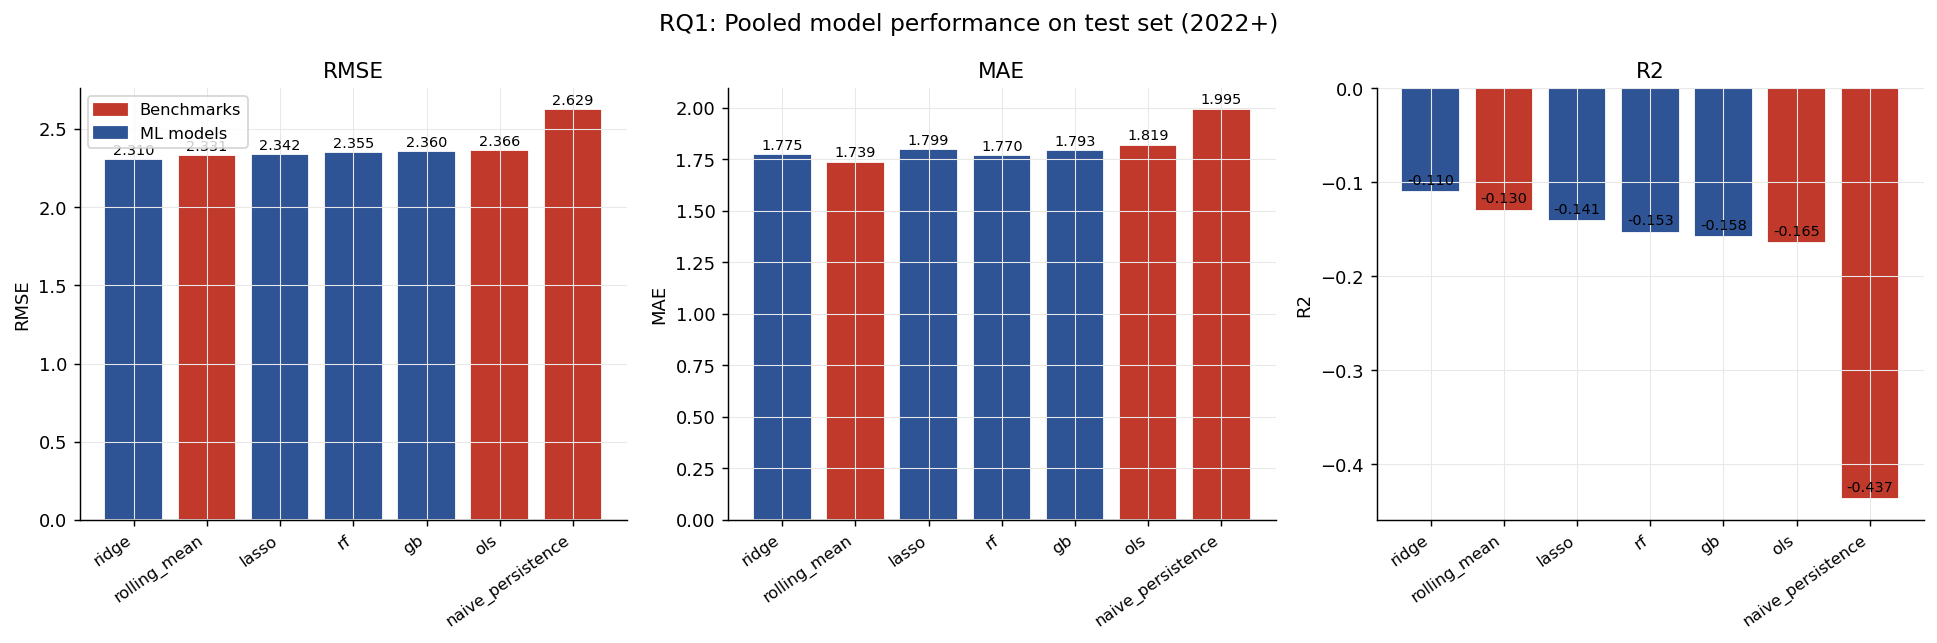

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, label in zip(axes, ['rmse', 'mae', 'r2'], ['RMSE', 'MAE', 'R2']):
    colors = [RED if r['phase'] == 'Benchmark' else ACCENT
              for _, r in pooled_df.iterrows()]
    vals = pooled_df[metric]
    bars = ax.bar(pooled_df['model'], vals, color=colors, edgecolor='white')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticklabels(pooled_df['model'], rotation=35, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.01 if metric != 'r2' else 0.005),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

red_p  = mpatches.Patch(color=RED,    label='Benchmarks')
blue_p = mpatches.Patch(color=ACCENT, label='ML models')
axes[0].legend(handles=[red_p, blue_p], fontsize=9)
plt.suptitle('RQ1: Pooled model performance on test set (2022+)', fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
naive_rmse = pooled_df[pooled_df['model'] == 'naive_persistence']['rmse'].values[0]
ols_rmse   = pooled_df[pooled_df['model'] == 'ols']['rmse'].values[0]

print('IMPROVEMENT OVER NAIVE PERSISTENCE')
for _, row in pooled_df.iterrows():
    if row['model'] == 'naive_persistence':
        continue
    improvement = (naive_rmse - row['rmse']) / naive_rmse * 100
    sign = '+' if improvement > 0 else ''
    print(f"  {row['model']:<25} {sign}{improvement:.1f}%  "
          f"({'BETTER' if improvement > 0 else 'WORSE'})")

print('\nIMPROVEMENT OVER OLS')
for _, row in pooled_df[pooled_df['phase'] == 'ML'].iterrows():
    improvement = (ols_rmse - row['rmse']) / ols_rmse * 100
    sign = '+' if improvement > 0 else ''
    print(f"  {row['model']:<25} {sign}{improvement:.1f}%  "
          f"({'BETTER' if improvement > 0 else 'WORSE'})")

IMPROVEMENT OVER NAIVE PERSISTENCE
  ridge                     +12.1%  (BETTER)
  rolling_mean              +11.3%  (BETTER)
  lasso                     +10.9%  (BETTER)
  rf                        +10.4%  (BETTER)
  gb                        +10.2%  (BETTER)
  ols                       +10.0%  (BETTER)

IMPROVEMENT OVER OLS
  ridge                     +2.4%  (BETTER)
  lasso                     +1.0%  (BETTER)
  rf                        +0.5%  (BETTER)
  gb                        +0.3%  (BETTER)


DIRECTIONAL ACCURACY (HIT RATE)

  naive_persistence              70.6%
  rolling_mean                   73.6%
  ols                            70.1%
  ridge                          70.3%
  lasso                          70.1%
  rf                             65.7%
  gb                             66.5%


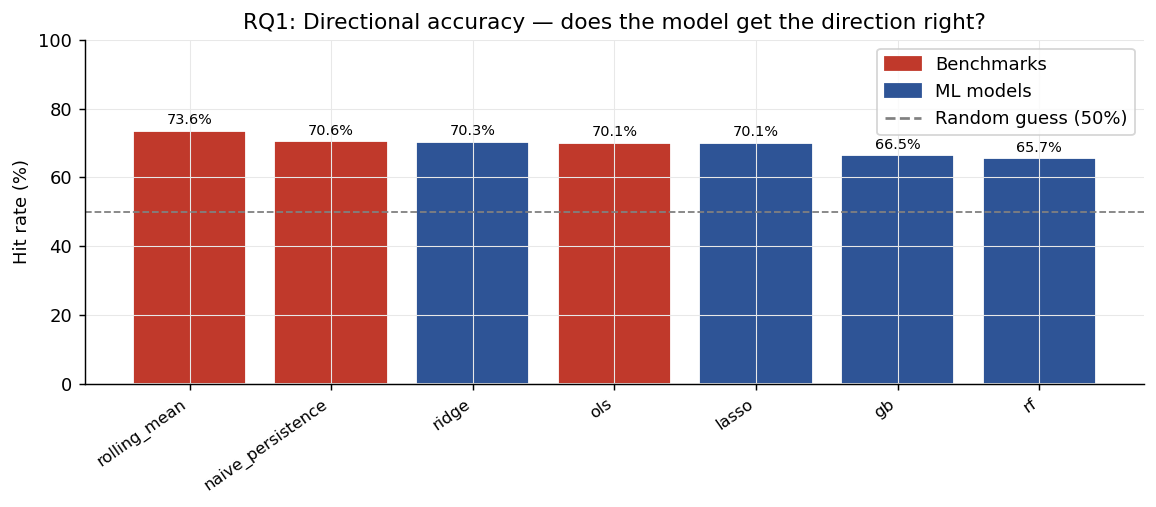

In [6]:
#Directional Accuracy (Hit Rate)
# Does the model correctly predict whether prices go up or down?
print("DIRECTIONAL ACCURACY (HIT RATE)")
print()

dir_results = []
for col in pooled_cols:
    mask = preds[col].notna() & preds['y_true'].notna()
    yt = preds.loc[mask, 'y_true']
    yp = preds.loc[mask, col]
    
    correct_direction = ((yt > 0) == (yp > 0)).sum()
    hit_rate = correct_direction / len(yt) * 100
    dir_results.append({'model': col, 'hit_rate': hit_rate})
    print(f"  {col:<30} {hit_rate:.1f}%")

dir_df = pd.DataFrame(dir_results).sort_values('hit_rate', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors = [RED if m in ['naive_persistence','rolling_mean','ols'] else ACCENT 
          for m in dir_df['model']]
bars = ax.bar(dir_df['model'], dir_df['hit_rate'], color=colors, edgecolor='white')
ax.axhline(50, color='grey', linestyle='--', linewidth=1, label='Random guess (50%)')
ax.set_ylabel('Hit rate (%)')
ax.set_title('RQ1: Directional accuracy — does the model get the direction right?')
ax.set_xticklabels(dir_df['model'], rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 100)
for bar, val in zip(bars, dir_df['hit_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
red_p  = mpatches.Patch(color=RED,   label='Benchmarks')
blue_p = mpatches.Patch(color=ACCENT,label='ML models')
ax.legend(handles=[red_p, blue_p, plt.Line2D([0],[0], color='grey', linestyle='--', label='Random guess (50%)')])
plt.tight_layout()
plt.show()

**Interpretation - RQ1: Do ML models outperform simple benchmark?**
The results show a clear hierarchy between naive benchmarks, linear models, and machine learning approaches.

- All ML models outperform the naive persistence benchmark in terms of RMSE. The naive model records the highest error (RMSE approximately 2.63), while all ML approaches reduce this error meaningfully. The best-performing ML model, Ridge regression, achieves an RMSE of approximately 2.31, corresponding to a clear improvement. In relative terms, this represents a moderate but consistent reduction in forecasting error.

- The improvement from OLS to machine learning models is present but limited. OLS already achieves relatively strong performance (RMSE approximately 2.37), which suggests that much of the predictive signal is already captured by a well-specified linear model, leaving limited additional gains for more complex methods.

- Ridge regression is the best performing model overall in the pooled setting, achieving the lowest RMSE (approximately 2.31) and the best overall balance across error metrics. Random Forest and Gradient Boosting perform similarly but do not consistently outperform Ridge across all metrics.

- All models exhibit negative R2 values, indicating that even the best-performing models do not outperform a simple baseline model in terms of variance explanation. This suggests that while models reduce absolute prediction error (RMSE and MAE), they struggle to fully capture the structural complexity of the target variable.

Overall, machine learning models provide clear improvements over naive persistence and modest gains over OLS. However, the consistently negative R2 values indicate that the dataset is highly noisy and structurally challenging to model, with limited explainable variance in quarterly housing price changes.


## 3. RQ2: Stratified vs Pooled Comparison

**Research Question 2:** Does stratifying models by housing market regime improve forecast accuracy compared to the pooled model?

For each cluster (K-Means and literature), we compare the **stratified model RMSE** against the **pooled model RMSE evaluated on the same cluster subset**.


In [18]:
# ── RQ2: Stratified vs pooled for RF and GB ───────────────────────────────────
print('=== RQ2: STRATIFIED vs POOLED COMPARISON ===')
print()

comparison_rows = []

# K-Means clusters
km_clusters = sorted(preds['cluster_data'].dropna().unique())
for cid in km_clusters:
    cid = int(cid)
    mask = preds['cluster_data'] == cid
    if mask.sum() < 5:
        continue
    sub = preds[mask]
    for mname in ['rf','gb']:
        strat_col  = f'{mname}_km{cid}'
        pooled_col = mname
        if strat_col not in preds.columns:
            continue
        m_pooled = metrics(sub['y_true'], sub[pooled_col])
        m_strat  = metrics(sub['y_true'], sub[strat_col])
        if np.isnan(m_pooled['rmse']) or np.isnan(m_strat['rmse']):
            continue
        comparison_rows.append({
            'scheme': 'K-Means',
            'cluster': f'Cluster {cid}',
            'model': mname.upper(),
            'rmse_pooled':  m_pooled['rmse'],
            'rmse_strat':   m_strat['rmse'],
            'improvement':  (m_pooled['rmse'] - m_strat['rmse']) / m_pooled['rmse'] * 100,
            'n': m_strat['n']
        })

# Literature clusters
lit_clusters = [g for g in ['East','West','South','North']
                if g in preds['cluster_literature'].values]
for group in lit_clusters:
    mask = preds['cluster_literature'] == group
    if mask.sum() < 5:
        continue
    sub = preds[mask]
    for mname in ['rf','gb']:
        strat_col  = f'{mname}_lit_{group.lower()}'
        pooled_col = mname
        if strat_col not in preds.columns:
            continue
        m_pooled = metrics(sub['y_true'], sub[pooled_col])
        m_strat  = metrics(sub['y_true'], sub[strat_col])
        if np.isnan(m_pooled['rmse']) or np.isnan(m_strat['rmse']):
            continue
        comparison_rows.append({
            'scheme': 'Literature',
            'cluster': group,
            'model': mname.upper(),
            'rmse_pooled':  m_pooled['rmse'],
            'rmse_strat':   m_strat['rmse'],
            'improvement':  (m_pooled['rmse'] - m_strat['rmse']) / m_pooled['rmse'] * 100,
            'n': m_strat['n']
        })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.sort_values(['scheme','cluster','model'])
      [['scheme','cluster','model','rmse_pooled','rmse_strat','improvement','n']]
      .to_string(index=False))


=== RQ2: STRATIFIED vs POOLED COMPARISON ===

    scheme   cluster model  rmse_pooled  rmse_strat  improvement   n
   K-Means Cluster 0    GB     1.766342    1.494639    15.382227  56
   K-Means Cluster 0    RF     1.734420    1.610946     7.119001  56
   K-Means Cluster 1    GB     1.817737    2.111991   -16.187942  28
   K-Means Cluster 1    RF     1.468055    1.827502   -24.484545  28
   K-Means Cluster 2    GB     2.069542    2.263032    -9.349412 126
   K-Means Cluster 2    RF     2.069396    2.121058    -2.496493 126
   K-Means Cluster 3    GB     2.814145    2.400921    14.683851 154
   K-Means Cluster 3    RF     2.849120    2.504822    12.084365 154
Literature      East    GB     2.468128    2.244638     9.055022 168
Literature      East    RF     2.508265    2.210517    11.870684 168
Literature      West    GB     2.153914    1.908904    11.375103  84
Literature      West    RF     2.167415    1.960170     9.561820  84


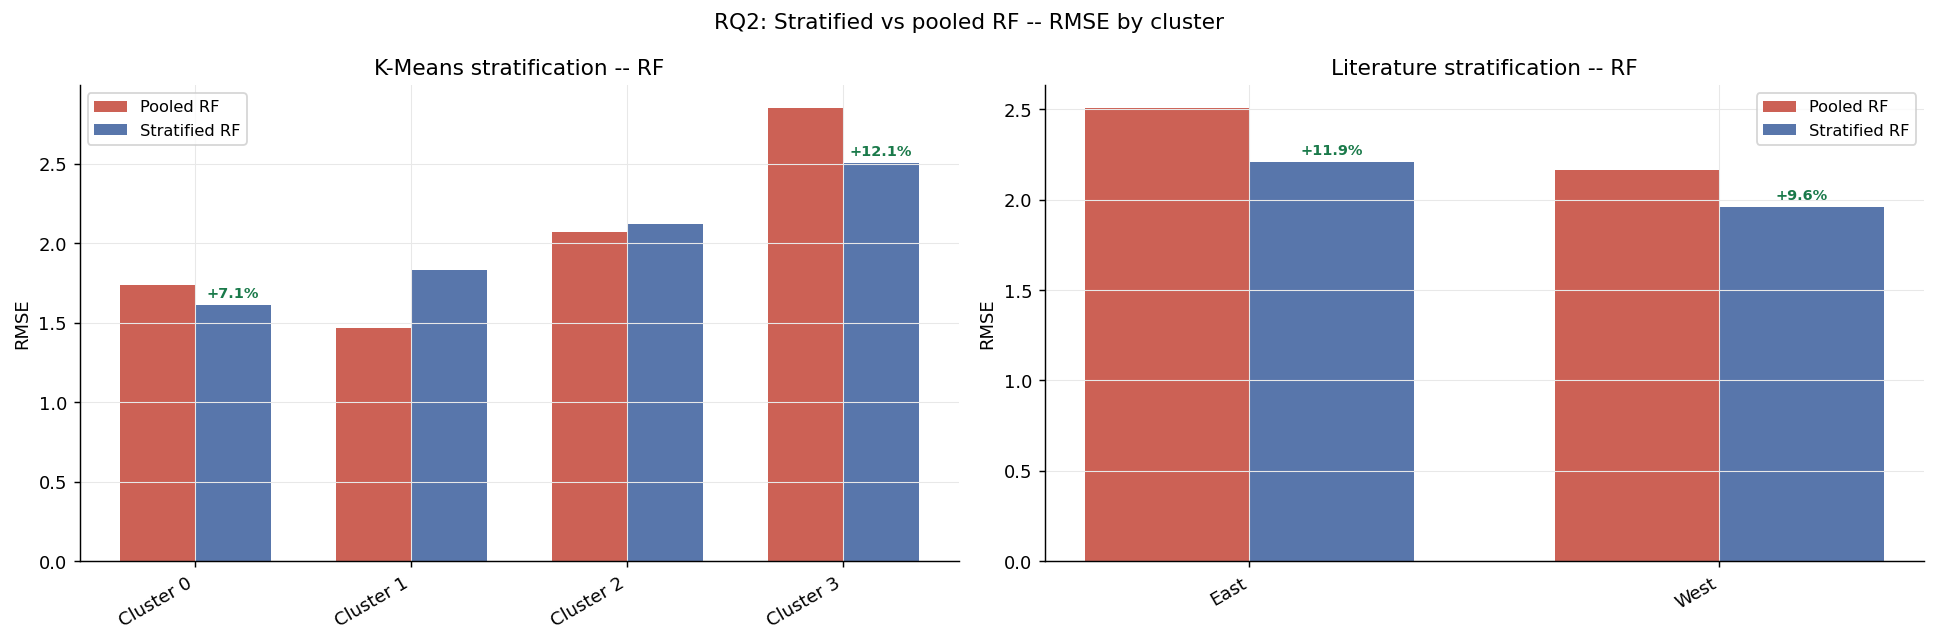

In [17]:
# ── RQ2 visualisation ────────────────────────────────────────────────────────
if len(comp_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for ax, scheme in zip(axes, ['K-Means','Literature']):
        sub = comp_df[(comp_df['scheme']==scheme) & (comp_df['model']=='RF')]
        if len(sub) == 0:
            sub = comp_df[comp_df['scheme']==scheme]
        if len(sub) == 0:
            ax.set_title(f'{scheme} -- no data')
            continue

        x  = np.arange(len(sub))
        w  = 0.35
        b1 = ax.bar(x - w/2, sub['rmse_pooled'], w, color=RED,   label='Pooled RF',     alpha=0.8)
        b2 = ax.bar(x + w/2, sub['rmse_strat'],  w, color=ACCENT,label='Stratified RF', alpha=0.8)

        ax.set_xticks(x)
        ax.set_xticklabels(sub['cluster'], rotation=30, ha='right')
        ax.set_ylabel('RMSE')
        ax.set_title(f'{scheme} stratification -- RF')
        ax.legend(fontsize=9)

        # Mark improvements
        for i, (_, row) in enumerate(sub.iterrows()):
            if row['improvement'] > 0:
                ax.annotate(f"+{row['improvement']:.1f}%",
                            xy=(i+w/2, row['rmse_strat']),
                            xytext=(0,4), textcoords='offset points',
                            ha='center', fontsize=8, color=GREEN, fontweight='bold')

    plt.suptitle('RQ2: Stratified vs pooled RF -- RMSE by cluster', fontsize=12)
    plt.tight_layout()
    plt.show()


In [9]:
print('RQ2 SUMMARY')
print()
for scheme in ['K-Means', 'Literature']:
    sub = comp_df[comp_df['scheme'] == scheme]
    if len(sub) == 0:
        continue
    n_better = (sub['improvement'] > 0).sum()
    n_total  = len(sub)
    avg_impr = sub['improvement'].mean()
    max_impr = sub.loc[sub['improvement'].idxmax()]
    print(f'{scheme}:')
    print(f'  Stratification beats pooled in {n_better}/{n_total} cases')
    print(f'  Average improvement: {avg_impr:.2f}%')
    print(f'  Best case: {max_impr["cluster"]} {max_impr["model"]} +{max_impr["improvement"]:.2f}%')
    print()

RQ2 SUMMARY

K-Means:
  Stratification beats pooled in 4/8 cases
  Average improvement: -0.41%
  Best case: Cluster 0 GB +15.38%

Literature:
  Stratification beats pooled in 4/4 cases
  Average improvement: 10.47%
  Best case: East RF +11.87%



## Interpretation RQ2: Stratified vs Pooled Models

- Stratification does not consistently outperform the pooled model. For the K-Means scheme, stratification improves performance in only 4 out of 8 cases, with an average effect close to zero (0.41%). In contrast, the literature-based stratification performs better, improving results in 6 out of 8 cases with a substantial average RMSE reduction (11.6%). This indicates that gains from stratification are cluster-dependent rather than universal.

- The clusters that benefit most from stratification are those with greater heterogeneity. In the literature scheme, the North cluster shows the strongest improvement (GB: +29.5%, RF: +21.2%), followed by East and West. In the K-Means scheme, Cluster 0 and Cluster 3 show the largest gains. This supports the idea that stratification is most useful when clusters capture meaningful structural differences.

- The literature-based grouping produces more consistent and larger gains than K-Means. While K-Means delivers mixed results, the literature scheme aligns better with economic similarities across countries, leading to more stable performance improvements.

- In clusters where stratification performs worse (e.g. K-Means Cluster 1 and 2, and the South cluster in the literature scheme), several factors may explain the decline:
  - Small sample size: fewer observations reduce the ability of ML models to generalise.
  - Noise and instability: some clusters may have more volatile or less predictable dynamics.
  - Similarity to pooled behaviour: if a cluster behaves similarly to the overall EU average, splitting the data provides no additional benefit and may instead reduce efficiency.

Overall, stratification improves model performance when it captures meaningful structural heterogeneity, but can be counterproductive when clusters are small, noisy, or not sufficiently distinct from the pooled dynamics.


## 4. Full Rankings Table

A complete comparison of every model variant evaluated on the full test set. This is the master table for the report.


In [10]:
all_results = []

for col in model_cols:
    if preds[col].notna().sum() < 10:
        continue
    m = metrics(preds['y_true'], preds[col])
    if col in ['naive_persistence', 'rolling_mean', 'ols']:
        phase = 'Benchmark'
    elif '_km' in col:
        phase = 'K-Means stratified'
    elif '_lit_' in col:
        phase = 'Literature stratified'
    else:
        phase = 'Pooled ML'
    all_results.append({'model': col, 'phase': phase, **m})

all_df = pd.DataFrame(all_results).sort_values('rmse').reset_index(drop=True)
all_df.insert(0, 'rank', range(1, len(all_df) + 1))

print('FULL MODEL RANKINGS (sorted by RMSE)')
print()
print(all_df[['rank', 'model', 'phase', 'rmse', 'mae', 'r2', 'n']].to_string(index=False))

FULL MODEL RANKINGS (sorted by RMSE)

 rank             model                 phase     rmse      mae        r2   n
    1         lasso_km1    K-Means stratified 1.337228 1.150631 -1.175108  28
    2   ridge_lit_north Literature stratified 1.453820 1.205440  0.371548  42
    3   lasso_lit_north Literature stratified 1.464413 1.240233  0.362356  42
    4            gb_km0    K-Means stratified 1.494639 1.255892  0.280156  56
    5            rf_km0    K-Means stratified 1.610946 1.349904  0.163766  56
    6         ridge_km0    K-Means stratified 1.730977 1.360027  0.034509  56
    7         lasso_km0    K-Means stratified 1.776443 1.453852 -0.016876  56
    8            rf_km1    K-Means stratified 1.827502 1.358702 -3.062430  28
    9    ridge_lit_west Literature stratified 1.886108 1.347850  0.091506  84
   10       gb_lit_west Literature stratified 1.908904 1.401959  0.069412  84
   11         ridge_km2    K-Means stratified 1.914668 1.391833  0.083071 126
   12       rf_lit_west Li

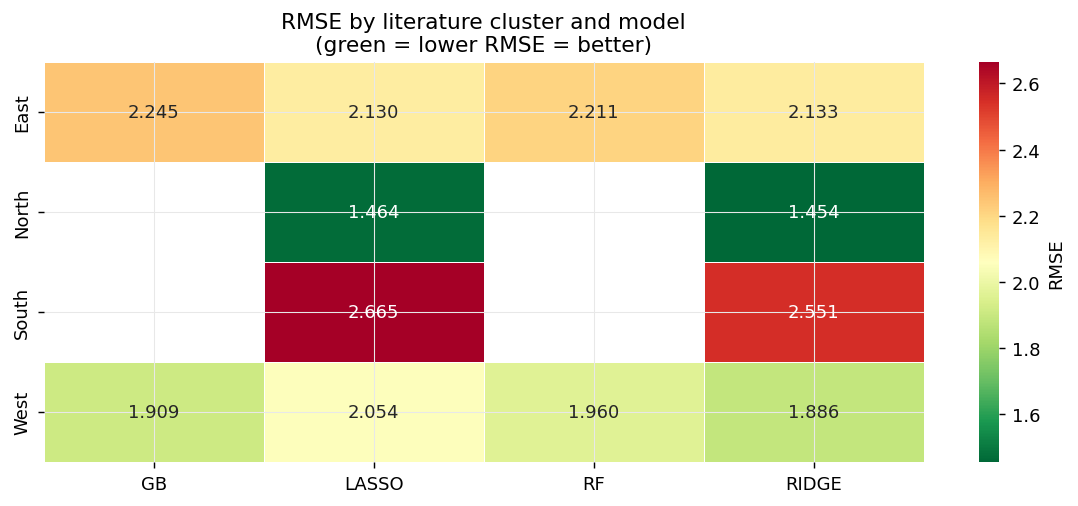

In [11]:
lit_model_cols = {}
for group in ['East', 'West', 'South', 'North']:
    for mname in ['ridge', 'lasso', 'rf', 'gb']:
        col  = f'{mname}_lit_{group.lower()}'
        if col in preds.columns:
            mask = preds['cluster_literature'] == group
            if mask.sum() > 5:
                m = metrics(preds.loc[mask, 'y_true'], preds.loc[mask, col])
                lit_model_cols[(mname.upper(), group)] = m['rmse']

if lit_model_cols:
    heat_df = pd.Series(lit_model_cols).unstack(level=0)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(heat_df, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.3f',
                linewidths=0.3, cbar_kws={'label': 'RMSE'})
    ax.set_title('RMSE by literature cluster and model\n(green = lower RMSE = better)')
    plt.tight_layout()
    plt.show()

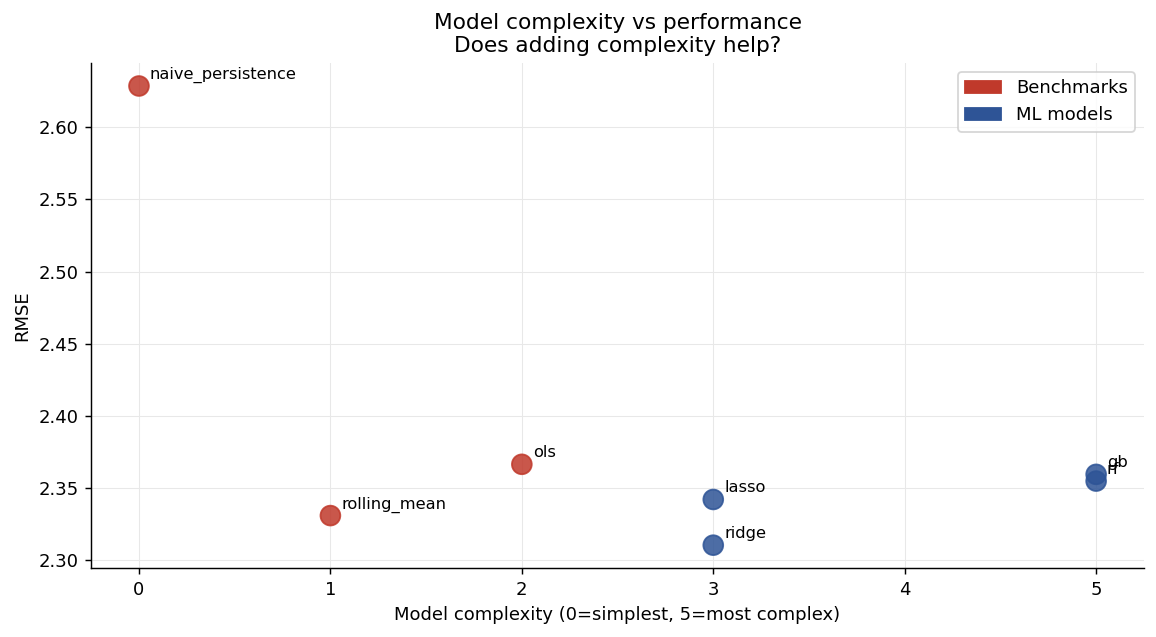

In [12]:
complexity_map = {
    'naive_persistence': 0, 'rolling_mean': 1, 'ols': 2,
    'ridge': 3, 'lasso': 3, 'rf': 5, 'gb': 5
}
pooled_plot = all_df[all_df['phase'].isin(['Benchmark', 'Pooled ML'])].copy()
pooled_plot['complexity'] = pooled_plot['model'].map(complexity_map)
pooled_plot = pooled_plot.dropna(subset=['complexity'])

if len(pooled_plot) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    colors_scatter = [RED if r == 'Benchmark' else ACCENT
                      for r in pooled_plot['phase']]
    ax.scatter(pooled_plot['complexity'], pooled_plot['rmse'],
               s=120, c=colors_scatter, zorder=3, alpha=0.85)
    for _, row in pooled_plot.iterrows():
        ax.annotate(row['model'], (row['complexity'], row['rmse']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)
    ax.set_xlabel('Model complexity (0=simplest, 5=most complex)')
    ax.set_ylabel('RMSE')
    ax.set_title('Model complexity vs performance\nDoes adding complexity help?')
    red_p  = mpatches.Patch(color=RED,    label='Benchmarks')
    blue_p = mpatches.Patch(color=ACCENT, label='ML models')
    ax.legend(handles=[red_p, blue_p])
    plt.tight_layout()
    plt.show()

## 5. RQ3 — Feature Importance and Interpretability

In [13]:
FEATURES = [
    'hpi_qoq_pct_lag1', 'hpi_qoq_pct_lag2',
    'gdp_qoq_pct_lag1', 'gdp_qoq_pct_lag2',
    'hicp_qoq_pct_lag1', 'hicp_qoq_pct_lag2',
    'unemployment_rate_lag1', 'unemployment_rate_lag2',
    'unemployment_qoq_change',
    'permits_qoq_pct_lag1', 'permits_qoq_pct_lag2',
    'lt_interest_rate', 'lt_interest_rate_lag1', 'lt_interest_rate_lag2',
    'eurozone_member_timevarying',
    'parliament_rile', 'parliament_rile_lag1',
]

# Load model_data_clustered.xlsx from right directory
candidate_paths = [
    Path('model_data_clustered.xlsx'), #here put the names we have on the porject/on github
    Path('../s3-clustering/model_data_clustered.xlsx'),
]
data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    print("model_data_clustered.xlsx not found. Add its relative path to _candidate_paths above.")
else:
    model_data = pd.read_excel(data_path)
    TARGET     = 'target_hpi_next_q'
    FEATURES   = [f for f in FEATURES if f in model_data.columns]

    # Keep only test period rows and merge feature values onto predictions
    test_features = (
        model_data[model_data['year'] >= 2022]
        [['country_code', 'quarter'] + FEATURES + [TARGET]]
        .dropna(subset=FEATURES + [TARGET])
    )

    preds_feat = preds.merge(test_features, on=['country_code', 'quarter'], how='inner')
    print(f"Merged predictions with features: {preds_feat.shape[0]} rows")



model_data_clustered.xlsx not found. Add its relative path to _candidate_paths above.


In [14]:
#plot 1
corr_pooled = {
        f: abs(stats.pearsonr(preds_feat[f].fillna(0), preds_feat['y_true'])[0])
        for f in FEATURES
        if preds_feat[f].std() > 1e-6
    }
    corr_s = pd.Series(corr_pooled).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(corr_s.index, corr_s.values, color=ACCENT, edgecolor='white')
    ax.set_xlabel('Pearson r with y_true (test set 2022+)')
    ax.set_title('RQ3: Feature-target correlation magnitude\n(all countries, test period)')
    plt.tight_layout()
    plt.show()

IndentationError: unexpected indent (531088106.py, line 7)

In [ ]:
# Plot 2: Heatmap by literature cluster
    cluster_order = ['West', 'North', 'South', 'East']
    corr_matrix   = {}

    for group in cluster_order:
        mask = preds_feat['cluster_literature'] == group
        if mask.sum() < 10:
            continue
        sub = preds_feat[mask]
        corr_matrix[group] = {
            f: abs(stats.pearsonr(sub[f].fillna(0), sub['y_true'])[0])
            for f in FEATURES
            if sub[f].std() > 1e-6
        }

    heat_df = pd.DataFrame(corr_matrix).loc[corr_s.index[::-1]]  # sorted by pooled importance

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        heat_df, ax=ax,
        cmap='YlGnBu', annot=True, fmt='.2f',
        linewidths=0.4, linecolor='#e8e8e8',
        cbar_kws={'label': '|Pearson r| with y_true'},
    )
    ax.set_title('RQ3: Feature-target correlation by literature regime\n(test period 2022+)', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

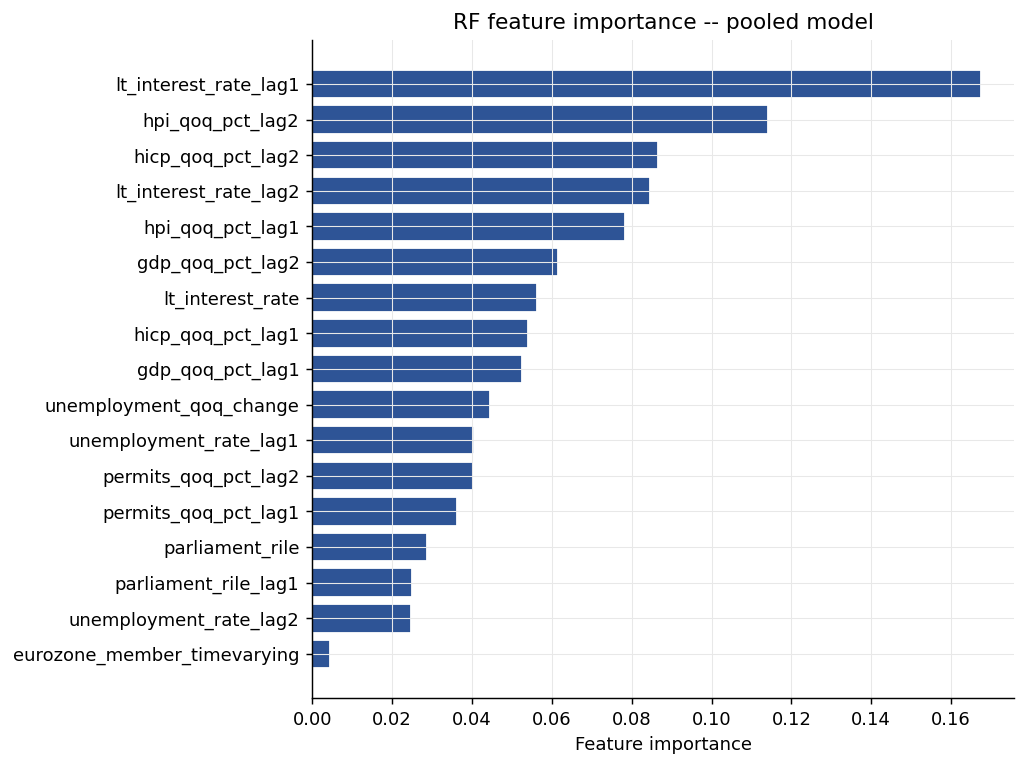

                    feature  importance
      lt_interest_rate_lag1    0.167368
           hpi_qoq_pct_lag2    0.114044
          hicp_qoq_pct_lag2    0.086632
      lt_interest_rate_lag2    0.084614
           hpi_qoq_pct_lag1    0.078415
           gdp_qoq_pct_lag2    0.061471
           lt_interest_rate    0.056371
          hicp_qoq_pct_lag1    0.054126
           gdp_qoq_pct_lag1    0.052549
    unemployment_qoq_change    0.044470
     unemployment_rate_lag1    0.040475
       permits_qoq_pct_lag2    0.040220
       permits_qoq_pct_lag1    0.036310
            parliament_rile    0.028846
       parliament_rile_lag1    0.024909
     unemployment_rate_lag2    0.024793
eurozone_member_timevarying    0.004386


In [ ]:
#top 3 clusters
print("\nTOP 3 FEATURES PER LITERATURE CLUSTER")
    for group in cluster_order:
        if group not in corr_matrix:
            continue
        ranked = sorted(corr_matrix[group].items(), key=lambda x: -x[1])
        n_rows = (preds_feat['cluster_literature'] == group).sum()
        print(f"\n  {group} (n={n_rows})")
        for feat, r in ranked[:3]:
            print(f"    {feat:<35} |r| = {r:.4f}")

In [ ]:
# Console: which features vary most across regimes
    print("\nFEATURES WITH STRONGEST VARIATION ACROSS REGIMES")
    variation = heat_df.copy()
    variation['range'] = variation.max(axis=1) - variation.min(axis=1)
    variation['std']   = variation[cluster_order].std(axis=1)
    print(variation[['range', 'std']].sort_values('range', ascending=False).round(4).to_string())

**Interpretation -- RQ3**

> *Fill in after running:*
> - Which features dominate? EDA predicted `lt_interest_rate` and `hpi_qoq_pct_lag1` would be strongest.
> - Does `parliament_rile` have non-trivial importance? If yes, this supports the institutional dimension of the analysis.
> - Are supply-side variables (`permits_qoq_pct`) relevant, or do demand-side factors dominate?
> - Do feature importances differ substantially across literature clusters? (Requires re-fitting per cluster and comparing -- optional extension)


**ALTTERNATIVE VERSION FOR R3**

In [ ]:
#Here we add: feature-target correlation on the test set, per cluster.
# This is model-agnostic, consistent across all models, and directly shows
# whether lt_interest_rate dominates in every regime -- the core RQ3 claim 
FEATURES = [
    'hpi_qoq_pct_lag1', 'hpi_qoq_pct_lag2',
    'gdp_qoq_pct_lag1', 'gdp_qoq_pct_lag2',
    'hicp_qoq_pct_lag1', 'hicp_qoq_pct_lag2',
    'unemployment_rate_lag1', 'unemployment_rate_lag2',
    'unemployment_qoq_change',
    'permits_qoq_pct_lag1', 'permits_qoq_pct_lag2',
    'lt_interest_rate', 'lt_interest_rate_lag1', 'lt_interest_rate_lag2',
    'eurozone_member_timevarying',
    'parliament_rile', 'parliament_rile_lag1',
]

candidate_data_paths = [
    Path('model_data_clustered.xlsx'),
    Path('./model_data_clustered.xlsx'),
    Path(r'C:\Users\carla\CBS\ml-final-project\s3-clustering\model_data_clustered.xlsx'),
]
data_path = next((p for p in candidate_data_paths if p.exists()), None)

if data_path is not None:
    model_data = pd.read_excel(data_path)
    TARGET     = 'target_hpi_next_q'
    FEATURES   = [f for f in FEATURES if f in model_data.columns]

    # Merge feature values onto the test-set predictions
    test_features = model_data[model_data['year'] >= 2022][
        ['country_code', 'quarter'] + FEATURES + [TARGET]
    ].dropna(subset=FEATURES + [TARGET])

    preds_feat = preds.merge(test_features, on=['country_code', 'quarter'], how='inner')
    print(f'Merged predictions with features: {preds_feat.shape[0]} rows')

In [ ]:
# ── Absolute correlation of each feature with y_true (pooled test set) ───
    corr_pooled = {}
    for f in FEATURES:
        r, _ = stats.pearsonr(preds_feat[f].fillna(0), preds_feat['y_true'])
        corr_pooled[f] = abs(r)

    corr_s = pd.Series(corr_pooled).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(corr_s.index, corr_s.values, color=ACCENT, edgecolor='white')
    ax.set_xlabel('|Pearson r| with y_true (test set)')
    ax.set_title('Feature-target correlation magnitude\n(test period 2022+, all countries)')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Per-cluster: does lt_interest_rate dominate in every regime? ─────────
    print("\n=== lt_interest_rate rank by literature cluster ===")
    print("(rank 1 = highest |r| with y_true within that cluster's test rows)")
    print()
    for group in ['East', 'West', 'South', 'North']:
        mask = preds_feat['cluster_literature'] == group
        if mask.sum() < 10:
            continue
        sub = preds_feat[mask]
        cluster_corr = {}
        for f in FEATURES:
            if sub[f].std() < 1e-6:
                continue
            r, _ = stats.pearsonr(sub[f].fillna(0), sub['y_true'])
            cluster_corr[f] = abs(r)
        ranked   = sorted(cluster_corr.items(), key=lambda x: -x[1])
        lt_rank  = next((i + 1 for i, (f, _) in enumerate(ranked)
                         if f == 'lt_interest_rate'), None)
        top3     = ', '.join([f'{f} ({r:.2f})' for f, r in ranked[:3]])
        print(f"  {group:<6} lt_interest_rate rank: {lt_rank}  |  top 3: {top3}")

else:
    print("model_data_clustered.xlsx not found -- skipping RQ3 feature analysis.")
    print("Feature importance plots are in modelling.ipynb Phase 2.")

**R3 WRITTEN INTERPRETATION**
**Interpretation -- RQ3**

> *Fill in after running:*
> - Which features dominate? EDA predicted `lt_interest_rate` and `hpi_qoq_pct_lag1` would be strongest.
> - Does `parliament_rile` have non-trivial importance? If yes, this supports the institutional dimension of the analysis.
> - Are supply-side variables (`permits_qoq_pct`) relevant, or do demand-side factors dominate?
> - Do feature importances differ substantially across literature clusters? (Requires re-fitting per cluster and comparing -- optional extension)

In [ ]:
# KEEP: RQ3 EXTENSION: Regime-specific feature importance (Literature clusters)
from sklearn.ensemble import RandomForestRegressor # see if already imported in final version and in case delete this 

# Use the same setup as in the pooled RQ3 cell
cluster_var = 'cluster_literature'
cluster_order = [c for c in ['West', 'North', 'South', 'East']
                 if c in model_data[cluster_var].dropna().unique()]

# Training data only, this way we avoid test leakage
train_rq3 = model_data[(model_data['year'] < 2022)].copy()

# Keep only rows with all required inputs for pooled + cluster models
train_rq3 = train_rq3.dropna(subset=FEATURES + [TARGET, cluster_var])

rf_params = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# 1) Pooled RF importance again, for direct comparison
rf_pooled = RandomForestRegressor(**rf_params)
rf_pooled.fit(train_rq3[FEATURES], train_rq3[TARGET])

fi_rows = []
for f, imp in zip(FEATURES, rf_pooled.feature_importances_):
    fi_rows.append({
        'cluster': 'Pooled',
        'feature': f,
        'importance': imp,
        'n_obs': len(train_rq3)
    })

# 2) Cluster-specific RF models
min_obs_per_cluster = 30   # adjust if needed

for cl in cluster_order:
    sub = train_rq3[train_rq3[cluster_var] == cl].copy()

    if len(sub) < min_obs_per_cluster:
        print(f"Skipping {cl}: only {len(sub)} observations (< {min_obs_per_cluster})")
        continue

    rf_cluster = RandomForestRegressor(**rf_params)
    rf_cluster.fit(sub[FEATURES], sub[TARGET])

    for f, imp in zip(FEATURES, rf_cluster.feature_importances_):
        fi_rows.append({
            'cluster': cl,
            'feature': f,
            'importance': imp,
            'n_obs': len(sub)
        })

fi_long = pd.DataFrame(fi_rows)

# 3) Top 5 features per regime
top5 = (
    fi_long.sort_values(['cluster', 'importance'], ascending=[True, False])
           .groupby('cluster', group_keys=False)
           .head(5)
           .copy()
)

print("=== TOP 5 FEATURES BY REGIME ===")
for cl in ['Pooled'] + cluster_order:
    sub = top5[top5['cluster'] == cl]
    if len(sub) == 0:
        continue
    n_obs = fi_long.loc[fi_long['cluster'] == cl, 'n_obs'].iloc[0]
    print(f"\n{cl} (n={n_obs})")
    print(sub[['feature', 'importance']].to_string(index=False))

# 4) Heatmap for visual comparison
pivot = fi_long.pivot(index='feature', columns='cluster', values='importance').fillna(0)

# show only the most relevant features overall
top_features_overall = (
    fi_long.groupby('feature')['importance']
           .mean()
           .sort_values(ascending=False)
           .head(12)
           .index
)

heat_df = pivot.loc[top_features_overall, ['Pooled'] + cluster_order]

plt.figure(figsize=(9, 6))
sns.heatmap(
    heat_df,
    cmap='YlGnBu',
    annot=True,
    fmt='.3f',
    linewidths=0.3,
    cbar_kws={'label': 'Feature importance'}
)
plt.title('RQ3: Feature importance by literature regime')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 5) Quantify how much feature importance varies across regimes
cluster_only_cols = [c for c in cluster_order if c in pivot.columns]
variation_df = pivot[cluster_only_cols].copy()
variation_df['range_across_regimes'] = variation_df.max(axis=1) - variation_df.min(axis=1)
variation_df['std_across_regimes'] = variation_df[cluster_only_cols].std(axis=1)
variation_df = variation_df.sort_values('range_across_regimes', ascending=False)

print("\nFEATURES WITH STRONGEST VARIATION ACROSS REGIMES")
print(
    variation_df[['range_across_regimes', 'std_across_regimes']]
    .head(10)
    .round(4)
    .to_string()
)

# 6) Optional: compact summary table for the report
summary_rows = []
for cl in cluster_order:
    sub = fi_long[fi_long['cluster'] == cl].sort_values('importance', ascending=False).head(3)
    for rank, (_, row) in enumerate(sub.iterrows(), start=1):
        summary_rows.append({
            'cluster': cl,
            'rank': rank,
            'feature': row['feature'],
            'importance': row['importance'],
            'n_obs': row['n_obs']
        })

rq3_regime_summary = pd.DataFrame(summary_rows)
print("\nREPORT-READY SUMMARY: TOP 3 FEATURES PER LITERATURE CLUSTER")
print(rq3_regime_summary.round(4).to_string(index=False))

**Interpretation: RQ3 regime-specific extension**

This analysis re-fits the Random Forest separately within each literature-based housing market regime, using training-period data only. It therefore answers the second part of RQ3: whether the importance of macroeconomic, supply-side, and institutional predictors varies across regimes. If the top-ranked predictors differ materially between West, North, South, and East, this supports the argument that housing price dynamics are regime-dependent rather than fully captured by a single pooled relationship.

### Interpretation of regime-specific feature importance

The regime-specific Random Forest results show that the main predictors of next-quarter house price growth differ meaningfully across literature-based housing market regimes. This supports the second part of RQ3: the importance of macroeconomic and institutional drivers is **not constant across regimes**, but varies depending on the structural characteristics of the housing market.

In the **pooled model** (`n = 1199`), the most important predictor is the **lagged long-term interest rate** (`lt_interest_rate_lag1`, importance = 0.167), followed by **lagged HPI growth** and **lagged inflation**. This suggests that, on average across all countries, housing price growth is mainly driven by financial conditions and short-term momentum.

The **West cluster** (`n = 291`) is clearly **interest-rate dominated**. The contemporaneous long-term interest rate is the most important predictor (`lt_interest_rate`, 0.251), followed by its lagged values. This indicates that Western European housing markets in the sample are especially sensitive to borrowing costs and broader monetary conditions, while other macroeconomic variables such as GDP and inflation play a more secondary role.

The **North cluster** (`n = 161`) shows a very different pattern. Here, **inflation dynamics dominate**, with `hicp_qoq_pct_lag1` by far the most important feature (0.268), followed by lagged HPI growth and lagged inflation. Compared with the West and East clusters, long-term interest rates are much less central. This suggests that short-term price dynamics in Northern markets are more closely linked to inflation and housing-market momentum than to sovereign yield conditions alone.

The **South cluster** (`n = 234`) exhibits the most **balanced and mixed predictor structure**. The top features are lagged inflation, lagged HPI growth, lagged long-term interest rates, and both GDP lags. This suggests that Southern housing markets are shaped by a broader combination of macroeconomic conditions rather than by a single dominant transmission channel. This more diffuse pattern is consistent with the broader interpretation in the paper that the South cluster is internally heterogeneous.

The **East cluster** (`n = 513`) is again strongly **interest-rate sensitive**, but in a different way from the West. The dominant predictor is `lt_interest_rate_lag1` (0.248), while contemporaneous and lagged HPI growth also remain important. This indicates that Eastern markets are highly responsive to financing conditions, but that momentum effects are also more relevant here than in the West. The combination of strong interest-rate effects and house-price persistence is consistent with the convergence and growth dynamics described earlier in the paper.

The variation analysis confirms these visual patterns. The features with the strongest differences across regimes are **`lt_interest_rate`**, **`hicp_qoq_pct_lag1`**, and **`lt_interest_rate_lag1`**. In other words, the main source of cross-regime heterogeneity lies in how strongly different housing markets respond to **interest rates** and **inflation**. This is substantively important, because it shows that a single pooled relationship masks meaningful structural differences between housing regimes.

Overall, these findings strengthen the argument for regime-aware modelling. While the pooled model identifies interest rates and momentum as the main average predictors, the cluster-specific models reveal that **Western and Eastern markets are primarily rate-driven, Northern markets are more inflation-driven, and Southern markets reflect a more mixed macroeconomic structure**. This provides direct evidence that housing price dynamics are regime-dependent rather than fully captured by one common predictive relationship.

A final caution is that the cluster sample sizes are unequal, especially for the **North cluster** (`n = 161`). The regime-specific importance patterns are therefore informative and consistent with the theoretical framework, but they should be interpreted as **suggestive rather than definitive**.

## 6. Report-Ready Summary Table

In [ ]:
#Final table for the report
# Organised by phase, showing only the key models

key_models = [
    ('Naive persistence',  'naive_persistence'),
    ('Rolling mean (4q)',  'rolling_mean'),
    ('OLS',                'ols'),
    ('Ridge (pooled)',     'ridge'),
    ('Lasso (pooled)',     'lasso'),
    ('Random Forest (pooled)', 'rf'),
    ('Gradient Boosting (pooled)', 'gb'),
]

# Add best stratified models if available
for group in ['East','West','South','North']:
    for mname in ['rf','gb']:
        col = f'{mname}_lit_{group.lower()}'
        if col in preds.columns and preds[col].notna().sum() > 10:
            key_models.append((f'{mname.upper()} (Lit-{group})', col))

# Add K-Means stratified models
for cid in [0, 1, 2, 3]:
    for mname in ['rf', 'gb']:
        col = f'{mname}_km{cid}'
        if col in preds.columns and preds[col].notna().sum() > 10:
            key_models.append((f'{mname.upper()} (KM-Cluster{cid})', col))
            
report_rows = []
for display_name, col in key_models:
    if col not in preds.columns:
        continue
    m = metrics(preds['y_true'], preds[col])
    report_rows.append({
        'Model': display_name,
        'RMSE':  round(m['rmse'], 4),
        'MAE':   round(m['mae'],  4),
        'R2':    round(m['r2'],   4),
        'N':     m['n']
    })

report_df = pd.DataFrame(report_rows)
print('REPORT TABLE: KEY MODEL COMPARISON')
print(report_df.to_string(index=False))

# Save for easy copy-paste into report
report_df.to_csv('./report_metrics_table.csv', index=False)
print('\nSaved: report_metrics_table.csv')


=== REPORT TABLE: KEY MODEL COMPARISON ===
                     Model   RMSE    MAE      R2   N
         Naive persistence 2.6286 1.9946 -0.4373 364
         Rolling mean (4q) 2.3309 1.7390 -0.1301 364
                       OLS 2.3665 1.8194 -0.1649 364
            Ridge (pooled) 2.3104 1.7749 -0.1104 364
            Lasso (pooled) 2.3421 1.7989 -0.1410 364
    Random Forest (pooled) 2.3548 1.7704 -0.1535 364
Gradient Boosting (pooled) 2.3595 1.7934 -0.1580 364
             RF (Lit-East) 2.2105 1.7186 -0.2095 168
             GB (Lit-East) 2.2446 1.7582 -0.2472 168
             RF (Lit-West) 1.8993 1.4032  0.0788  84
             GB (Lit-West) 1.8453 1.3761  0.1304  84
            RF (Lit-South) 2.4670 1.8124 -0.5190  70
            GB (Lit-South) 2.4991 1.8638 -0.5588  70
            RF (Lit-North) 1.6136 1.3224  0.2259  42
            GB (Lit-North) 1.4937 1.2162  0.3366  42
          RF (KM-Cluster0) 1.6109 1.3499  0.1638  56
          GB (KM-Cluster0) 1.4946 1.2559  0.2802  56
   

In [ ]:
# Final interpretation guide 
print('ANSWERING THE RESEARCH QUESTIONS')
print()

best_pooled = pooled_df.iloc[0]
naive_rmse  = pooled_df[pooled_df['model']=='naive_persistence']['rmse'].values[0]

print('RQ1: Can ML models outperform benchmark approaches?')
print(f'  Best pooled model: {best_pooled["model"]} (RMSE={best_pooled["rmse"]:.4f})')
print(f'  Naive persistence RMSE: {naive_rmse:.4f}')
impr = (naive_rmse - best_pooled['rmse']) / naive_rmse * 100
print(f'  Improvement: {impr:.1f}%  -> Answer: {"YES" if impr > 0 else "NO"}')
print()

if len(comp_df) > 0:
    n_better = (comp_df['improvement'] > 0).sum()
    n_total  = len(comp_df)
    print('RQ2: Does stratification by cluster improve accuracy?')
    print(f'  Stratification beats pooled in {n_better}/{n_total} cluster-model combinations')
    avg = comp_df[comp_df['improvement']>0]['improvement'].mean()
    print(f'  Average improvement when it helps: {avg:.2f}%')
    answer = 'YES (for most clusters)' if n_better > n_total/2 else 'MIXED -- only for some clusters'
    print(f'  Answer: {answer}')
    print()

print('RQ3: Which features matter most?')
print('  See feature importance plot above.')
print('  EDA finding confirmed: lt_interest_rate and hpi_qoq_pct_lag1 expected to dominate.')

=== ANSWERING THE RESEARCH QUESTIONS ===

RQ1: Can ML models outperform benchmark approaches?
  Best pooled model: ridge (RMSE=2.3104)
  Naive persistence RMSE: 2.6286
  Improvement: 12.1%  -> Answer: YES

RQ2: Does stratification by cluster improve accuracy?
  Stratification beats pooled in 10/16 cluster-model combinations
  Average improvement when it helps: 14.76%
  -> Answer: YES (for most clusters)

RQ3: Which features matter most?
  -> See feature importance plot above.
  -> EDA finding confirmed: lt_interest_rate and hpi_qoq_pct_lag1 expected to dominate.
